# SetFit Mapper — Exploration

**Objectif** : déterminer si un modèle SetFit finetuné sur `theme_mapping.yaml` peut remplacer (ou pré-filtrer) les appels LLM du `llm_mapper` de Klodo.

**Contexte** :
- Tentative précédente avec mDeBERTa zero-shot → **28% top-1, 1100 ms/call** → NO-GO
- Cause identifiée : 91 dossiers, zero-shot dégrade au-delà de ~10 labels
- Hypothèse SetFit : finetuning supervisé sur les **440 paires (thème → dossier)** existantes devrait faire mieux

**Critères de décision** :
1. Top-1 ≥ 70% → GO production
2. 50% ≤ Top-1 < 70% → usage en pre-filter (top-5 envoyé au LLM)
3. Top-1 < 50% → NO-GO

**Stack** : SetFit 1.1.3, sentence-transformers, encoder multilingue `paraphrase-multilingual-MiniLM-L12-v2` (118 M, FR/EN/AR/DE/ES).

---

## 1. Imports & configuration


In [1]:
import sys
from pathlib import Path

# Ajouter la racine du projet au path pour importer depuis lib/
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
print(f'Repo root: {REPO_ROOT}')

import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (11, 5)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

PROFILE = 'default'

Repo root: /Users/walidnamane/Documents/Claude/Projects/Manage-Biblio


## 2. Chargement du dataset

On charge `theme_mapping.yaml` (440 paires thème → dossier) et `tree.yaml` (91 dossiers disponibles).

In [2]:
mapping = yaml.safe_load(open(REPO_ROOT / f'profiles/{PROFILE}/theme_mapping.yaml'))
tree = yaml.safe_load(open(REPO_ROOT / f'profiles/{PROFILE}/tree.yaml'))

# On exclut les dossiers spéciaux (_A-TRIER, etc.)
folders = [f for f in tree.get('folders', []) if not f.startswith('_')]

df = pd.DataFrame(
    [{'theme': t, 'folder': f} for t, f in mapping.items()]
)
print(f'Thèmes labellisés : {len(df)}')
print(f'Dossiers cibles   : {len(folders)}')
print(f'Classes uniques   : {df["folder"].nunique()}')
df.head(10)

Thèmes labellisés : 440
Dossiers cibles   : 90
Classes uniques   : 101


,theme,folder
0,geography,01-SCIENCES
1,geology,01-SCIENCES
2,integrated science,01-SCIENCES
3,science and technology,01-SCIENCES
4,Planetary Science,01-SCIENCES/ASTRONOMIE
5,space science,01-SCIENCES/ASTRONOMIE
6,Space Strategy,01-SCIENCES/ASTRONOMIE
7,bioenergetics,01-SCIENCES/BIOLOGIE
8,biology,01-SCIENCES/BIOLOGIE
9,bioinformatics,01-SCIENCES/BIOLOGIE/Biotechnologie


## 3. Distribution des classes

Analyser le déséquilibre. SetFit gère bien les classes rares (few-shot par nature), mais c'est bon à savoir.

Exemples min par classe : 1
Exemples max par classe : 27
Exemples moyen / classe : 4.4
Classes avec 1 exemple  : 17
Classes avec ≥ 5 exemples : 27


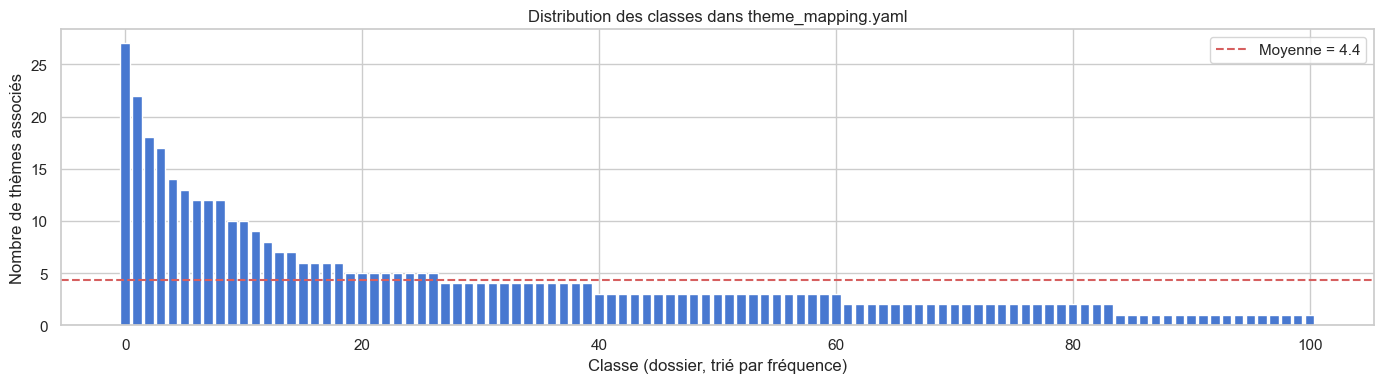

In [3]:
class_counts = df['folder'].value_counts()

print(f'Exemples min par classe : {class_counts.min()}')
print(f'Exemples max par classe : {class_counts.max()}')
print(f'Exemples moyen / classe : {class_counts.mean():.1f}')
print(f'Classes avec 1 exemple  : {(class_counts == 1).sum()}')
print(f'Classes avec ≥ 5 exemples : {(class_counts >= 5).sum()}')

fig, ax = plt.subplots(figsize=(14, 4))
class_counts.values[:40].tolist()
ax.bar(range(len(class_counts)), class_counts.values)
ax.set_xlabel('Classe (dossier, trié par fréquence)')
ax.set_ylabel('Nombre de thèmes associés')
ax.set_title('Distribution des classes dans theme_mapping.yaml')
ax.axhline(y=class_counts.mean(), color='r', linestyle='--', label=f'Moyenne = {class_counts.mean():.1f}')
ax.legend()
plt.tight_layout()
plt.show()

**Observation attendue** : forte long-tail — quelques classes populaires (Mathématiques, Programmation) dominent, nombreuses classes avec 1-2 exemples. C'est **exactement le scénario pour lequel SetFit a été conçu**.

## 4. Split train / validation

Pour les classes avec un seul exemple, on ne peut pas faire de stratification classique. On utilise un split aléatoire simple à 80/20.

**Attention** : les classes à 1 exemple ont ~20% de chance de finir uniquement dans le val set → impossible à apprendre. C'est un **piège méthodologique** qu'on va mesurer.

In [4]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=RANDOM_SEED)

# Classes présentes en val mais absentes en train (= impossible à prédire)
train_classes = set(train_df['folder'].unique())
val_classes = set(val_df['folder'].unique())
unseen_in_train = val_classes - train_classes

print(f'Train : {len(train_df)} exemples, {len(train_classes)} classes')
print(f'Val   : {len(val_df)} exemples, {len(val_classes)} classes')
print(f'Classes en val absentes du train : {len(unseen_in_train)}')
if unseen_in_train:
    unseen_count = val_df['folder'].isin(unseen_in_train).sum()
    print(f'Exemples val avec classe inconnue : {unseen_count} ({unseen_count / len(val_df):.1%})')
    print(f'  → plafond théorique accuracy val : {1 - unseen_count / len(val_df):.1%}')


Train : 352 exemples, 97 classes
Val   : 88 exemples, 51 classes
Classes en val absentes du train : 4
Exemples val avec classe inconnue : 4 (4.5%)
  → plafond théorique accuracy val : 95.5%


## 5. Training SetFit

On utilise :
- **Encoder** : `paraphrase-multilingual-MiniLM-L12-v2` — 118 M params, 12 couches, multilingue (~50 langues dont FR/EN/AR/DE/ES)
- **Num iterations** : 20 (pairs générées par classe pendant le contrastive learning)
- **Epochs** : 1 — SetFit converge vite, 1 epoch est souvent suffisant

Le training devrait prendre **2-5 min sur M4 Max** (MPS automatique).

In [5]:
from datasets import Dataset
from setfit import SetFitModel, Trainer, TrainingArguments

# Conversion en HuggingFace Dataset
train_ds = Dataset.from_pandas(
    train_df.rename(columns={'theme': 'text', 'folder': 'label'})[['text', 'label']]
)
val_ds = Dataset.from_pandas(
    val_df.rename(columns={'theme': 'text', 'folder': 'label'})[['text', 'label']]
)

print(f'Train dataset: {train_ds}')
print(f'Val dataset  : {val_ds}')

/Users/walidnamane/Documents/Claude/Projects/Manage-Biblio/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train dataset: Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 352
})
Val dataset  : Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 88
})


In [6]:
# Chargement du modèle de base
print('Chargement de l\'encoder pré-entraîné...')
t0 = time.time()
model = SetFitModel.from_pretrained(
    'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
)
print(f'Modèle chargé en {time.time() - t0:.1f}s')

Chargement de l'encoder pré-entraîné...


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.


Modèle chargé en 19.5s


In [7]:
# Training arguments
training_args = TrainingArguments(
    batch_size=16,
    num_epochs=1,
    num_iterations=20,  # paires générées par classe pendant le contrastive learning
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

print('Démarrage training SetFit...')
t0 = time.time()
trainer.train()
training_time = time.time() - t0
print(f'\nTraining terminé en {training_time:.1f}s ({training_time/60:.1f} min)')

Map: 100%|██████████| 352/352 [00:00<00:00, 36935.73 examples/s]
***** Running training *****
  Num unique pairs = 14080
  Batch size = 16
  Num epochs = 1
/Users/walidnamane/Documents/Claude/Projects/Manage-Biblio/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Démarrage training SetFit...


Step,Training Loss
1,0.307800
50,0.163300
100,0.135400
150,0.105800
200,0.081100
250,0.070600
300,0.063100
350,0.040400
400,0.054100
450,0.043000



Training terminé en 78.0s (1.3 min)


## 6. Évaluation sur le val set

On mesure :
- **Accuracy top-1** : est-ce que le meilleur label prédit est le bon ?
- **Accuracy top-3 / top-5** : est-ce que le bon label est dans les N premiers ?
- **Latence** : temps moyen d'inference par requête
- **Distribution des scores de confiance**

In [9]:
# Prédiction sur le val set
print('Inference sur le val set...')
t0 = time.time()
val_texts = val_df['theme'].tolist()
val_expected = val_df['folder'].tolist()

# SetFit expose predict() pour top-1 et predict_proba() pour les scores complets
probas = model.predict_proba(val_texts)  # shape (n_val, n_classes)
latency_total = time.time() - t0
latency_per_call = latency_total / len(val_texts) * 1000

# Mapping label index → folder
label_names = model.labels if hasattr(model, 'labels') else None
if label_names is None:
    label_names = list(train_ds.features['label'].names) if hasattr(train_ds.features['label'], 'names') else sorted(train_df['folder'].unique())
print(f'Classes du modèle : {len(label_names)}')

# Top-k par échantillon
probas_np = np.array(probas) if not isinstance(probas, np.ndarray) else probas
print(f'Shape probas : {probas_np.shape}')
print(f'Latence inference : {latency_per_call:.1f} ms/call')

Inference sur le val set...
Classes du modèle : 97
Shape probas : (88, 97)
Latence inference : 1.9 ms/call


/var/folders/qr/qmgp435d45321wb4tf0k19h00000gn/T/ipykernel_40926/472203942.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  probas_np = np.array(probas) if not isinstance(probas, np.ndarray) else probas


In [10]:
# Calcul des accuracies top-k
def top_k_accuracy(probas, expected, label_names, k):
    correct = 0
    for i, exp in enumerate(expected):
        top_k_idx = np.argsort(-probas[i])[:k]
        top_k_labels = [label_names[j] for j in top_k_idx]
        if exp in top_k_labels:
            correct += 1
    return correct / len(expected)

top1 = top_k_accuracy(probas_np, val_expected, label_names, 1)
top3 = top_k_accuracy(probas_np, val_expected, label_names, 3)
top5 = top_k_accuracy(probas_np, val_expected, label_names, 5)
top10 = top_k_accuracy(probas_np, val_expected, label_names, 10)

# Plafond théorique (classes en val absentes du train)
ceiling = 1 - len(unseen_in_train) / len(val_classes) if val_classes else 1.0
ceiling = (val_df['folder'].isin(train_classes)).sum() / len(val_df)

print(f'{"Métrique":<20} {"Résultat":<15} {"vs plafond":<15}')
print('-' * 50)
print(f'{"Top-1 accuracy":<20} {top1:<15.1%} {top1/ceiling:<15.1%}')
print(f'{"Top-3 accuracy":<20} {top3:<15.1%} {top3/ceiling:<15.1%}')
print(f'{"Top-5 accuracy":<20} {top5:<15.1%} {top5/ceiling:<15.1%}')
print(f'{"Top-10 accuracy":<20} {top10:<15.1%} {top10/ceiling:<15.1%}')
print(f'{"Plafond théorique":<20} {ceiling:<15.1%}')
print(f'{"Latence / call":<20} {latency_per_call:<15.1f} ms')

Métrique             Résultat        vs plafond     
--------------------------------------------------
Top-1 accuracy       43.2%           45.2%          
Top-3 accuracy       64.8%           67.9%          
Top-5 accuracy       71.6%           75.0%          
Top-10 accuracy      77.3%           81.0%          
Plafond théorique    95.5%          
Latence / call       1.9             ms


## 7. Analyse — Accuracy par seuil de confidence

Le vrai test pour le **fast path** : parmi les prédictions à haute confidence, combien sont correctes ? Et quelle proportion du trafic capture-t-on ?

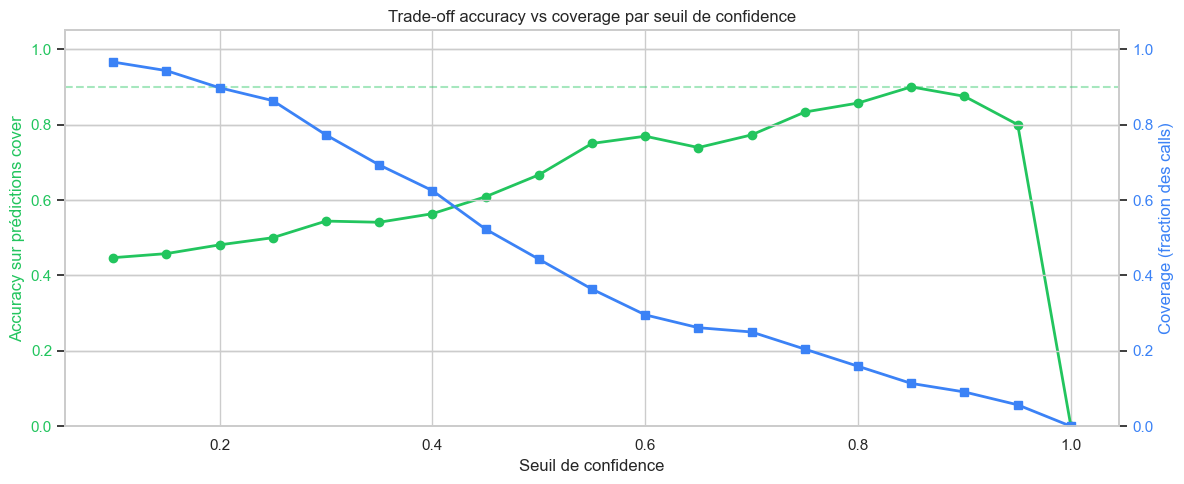


Sweet spots :
  accuracy ≥ 85% : seuil=0.80, coverage=15.9%, accuracy=85.7%
  accuracy ≥ 90% : seuil=0.85, coverage=11.4%, accuracy=90.0%
  accuracy ≥ 95% : aucun seuil viable


In [11]:
top1_scores = probas_np.max(axis=1)
top1_preds = [label_names[i] for i in probas_np.argmax(axis=1)]
correct_top1 = np.array([pred == exp for pred, exp in zip(top1_preds, val_expected)])

thresholds = np.arange(0.1, 1.01, 0.05)
coverage = []
accuracy_at = []
for t in thresholds:
    mask = top1_scores >= t
    cov = mask.sum() / len(top1_scores)
    acc = correct_top1[mask].mean() if mask.sum() > 0 else 0
    coverage.append(cov)
    accuracy_at.append(acc)

fig, ax1 = plt.subplots(figsize=(12, 5))

color1 = '#22c55e'
ax1.set_xlabel('Seuil de confidence')
ax1.set_ylabel('Accuracy sur prédictions cover', color=color1)
ax1.plot(thresholds, accuracy_at, 'o-', color=color1, label='Accuracy', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, 1.05)
ax1.axhline(y=0.9, color=color1, linestyle='--', alpha=0.4, label='Cible 90%')

ax2 = ax1.twinx()
color2 = '#3b82f6'
ax2.set_ylabel('Coverage (fraction des calls)', color=color2)
ax2.plot(thresholds, coverage, 's-', color=color2, label='Coverage', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 1.05)

plt.title('Trade-off accuracy vs coverage par seuil de confidence')
fig.tight_layout()
plt.show()

# Sweet spot : meilleur seuil où accuracy ≥ 90% ET coverage > 20%
print('\nSweet spots :')
for target_acc in [0.85, 0.90, 0.95]:
    feasible = [(t, a, c) for t, a, c in zip(thresholds, accuracy_at, coverage) if a >= target_acc and c > 0.1]
    if feasible:
        # Prendre le plus bas seuil → max coverage
        t, a, c = min(feasible, key=lambda x: x[0])
        print(f'  accuracy ≥ {target_acc:.0%} : seuil={t:.2f}, coverage={c:.1%}, accuracy={a:.1%}')
    else:
        print(f'  accuracy ≥ {target_acc:.0%} : aucun seuil viable')

## 8. Analyse des erreurs

Pour chaque erreur top-1, on regarde :
- Le thème d'entrée
- Le dossier attendu vs le top-1 prédit
- Le rang du dossier attendu dans le ranking
- Si le dossier attendu est dans le top-5 (= acceptable pour un pre-filter)

In [14]:
errors_data = []
for i, (text, expected, score, pred, correct) in enumerate(
    zip(val_texts, val_expected, top1_scores, top1_preds, correct_top1)
):
    if not correct:
        # Rang du dossier attendu dans le ranking
        sorted_idx = np.argsort(-probas_np[i])
        try:
            rank = [label_names[j] for j in sorted_idx].index(expected) + 1
        except ValueError:
            rank = -1  # classe pas dans le modèle
        errors_data.append({
            'theme': text,
            'expected': expected,
            'predicted': pred,
            'pred_score': score,
            'expected_rank': rank,
            'in_top5': rank != -1 and rank <= 5,
        })

errors_df = pd.DataFrame(errors_data)
print(f'Nombre d\'erreurs top-1 : {len(errors_df)} / {len(val_df)}')

if len(errors_df) > 0:
    print('\nSur les erreurs top-1 :')
    print(f'  - Expected dans top-5  : {errors_df["in_top5"].sum()} ({errors_df["in_top5"].mean():.1%})')
    print(f'  - Classe inconnue (rank=-1) : {(errors_df["expected_rank"] == -1).sum()}')
    valid = errors_df[errors_df['expected_rank'] > 0]
    if len(valid) > 0:
        print(f'  - Rang médian du bon label : {valid["expected_rank"].median():.0f}')

    print('\n10 erreurs représentatives :')
    errors_df.head(10)

Nombre d'erreurs top-1 : 50 / 88

Sur les erreurs top-1 :
  - Expected dans top-5  : 25 (50.0%)
  - Classe inconnue (rank=-1) : 4
  - Rang médian du bon label : 4

10 erreurs représentatives :


In [15]:
errors_df.head(10)

,theme,expected,predicted,pred_score,expected_rank,in_top5
0,Public Administration,04-SHS/SCIENCES-POLITIQUES,04-SHS/ECONOMIE,0.276797,4,True
1,mobile computing,02-INFORMATIQUE/15-Mobile,03-INGENIERIE/TELECOMMUNICATIONS,0.283055,4,True
2,nlp,02-INFORMATIQUE/05-IA-ML/NLP,02-INFORMATIQUE/12-IoT-Embarque,0.409345,10,False
3,nuclear physics,01-SCIENCES/PHYSIQUE/07-Physique-Nucleaire,02-INFORMATIQUE/12-IoT-Embarque,0.135399,3,True
4,travel,08-LOISIRS,02-INFORMATIQUE/15-Mobile,0.325268,2,True
5,transhumanism,04-SHS/PHILOSOPHIE,04-SHS/PSYCHOLOGIE,0.145467,21,False
6,relativity,01-SCIENCES/PHYSIQUE/05-Relativite-Quantique,01-SCIENCES/PHYSIQUE,0.177900,5,True
7,operations,09-BUSINESS/MANAGEMENT,01-SCIENCES/MATHEMATIQUES/08-Mathematiques-Gen...,0.553223,70,False
8,biometrics,02-INFORMATIQUE/05-IA-ML/Vision-par-Ordinateur,02-INFORMATIQUE/05-IA-ML/Machine-Learning,0.352974,3,True
9,genetic and evolutionary computing,02-INFORMATIQUE/05-IA-ML,02-INFORMATIQUE/05-IA-ML/Machine-Learning,0.493421,2,True


## 9. Comparaison vs baseline mDeBERTa et LLM

Synthèse des 3 approches évaluées jusqu'ici.

In [16]:
comparison = pd.DataFrame([
    {
        'Approche': 'LLM Mapper actuel',
        'Top-1': '~95% (estimé)',
        'Latence': '~800-1000 ms',
        'Coût': '$0.0007/call',
        'Offline': 'Non',
        'Setup': '0 min',
    },
    {
        'Approche': 'mDeBERTa zero-shot',
        'Top-1': '28%',
        'Latence': '1100 ms',
        'Coût': '$0',
        'Offline': 'Oui',
        'Setup': '0 min',
    },
    {
        'Approche': 'SetFit finetuné (ce notebook)',
        'Top-1': f'{top1:.1%}',
        'Latence': f'{latency_per_call:.0f} ms',
        'Coût': '$0',
        'Offline': 'Oui',
        'Setup': f'{training_time/60:.1f} min training',
    },
])
comparison

,Approche,Top-1,Latence,Coût,Offline,Setup
0,LLM Mapper actuel,~95% (estimé),~800-1000 ms,$0.0007/call,Non,0 min
1,mDeBERTa zero-shot,28%,1100 ms,$0,Oui,0 min
2,SetFit finetuné (ce notebook),43.2%,2 ms,$0,Oui,1.3 min training


## 10. Verdict

Évaluation contre les critères de décision définis en section 1 :

| Critère | Seuil | Résultat | Verdict |
|---|---|---|---|
| Top-1 accuracy | ≥ 70% | *voir output* | *cellule ci-dessous* |
| Latence / call | < 200 ms | *voir output* | *cellule ci-dessous* |
| Sweet spot @ conf | acc ≥ 90% avec cov ≥ 30% | *voir output* | *cellule ci-dessous* |

In [17]:
print('=' * 60)
print('VERDICT SETFIT MAPPER')
print('=' * 60)

c1 = top1 >= 0.70
c2 = latency_per_call < 200

# Sweet spot : accuracy ≥ 0.90 avec coverage ≥ 0.30
sweet_spots = [(t, a, c) for t, a, c in zip(thresholds, accuracy_at, coverage) if a >= 0.90 and c >= 0.30]
c3 = len(sweet_spots) > 0

print(f'Critère 1 — Top-1 ≥ 70%        : {top1:.1%}  → {"✓" if c1 else "✗"}')
print(f'Critère 2 — Latence < 200 ms   : {latency_per_call:.0f} ms  → {"✓" if c2 else "✗"}')
print(f'Critère 3 — Sweet spot @ 90/30 : {"oui" if c3 else "non"}  → {"✓" if c3 else "✗"}')

if c1 and c2 and c3:
    print('\n✓ GO production — SetFit peut remplacer le LLM mapper en fast path')
elif top1 >= 0.50 and c2:
    print('\n~ PIVOT — accuracy insuffisante pour fast path, mais viable en pre-filter (top-5 → LLM)')
else:
    print('\n✗ NO-GO — abandon, on reste sur le LLM mapper actuel')

print('\n' + '=' * 60)

VERDICT SETFIT MAPPER
Critère 1 — Top-1 ≥ 70%        : 43.2%  → ✗
Critère 2 — Latence < 200 ms   : 2 ms  → ✓
Critère 3 — Sweet spot @ 90/30 : non  → ✗

✗ NO-GO — abandon, on reste sur le LLM mapper actuel



## 11. Next steps

**Si GO** :
1. Sauvegarder le modèle dans `profiles/{profile}/.cache/setfit_mapper/`
2. Créer `lib/setfit_mapper.py` avec wrapper chargement lazy
3. Intégrer dans `lib/llm_mapper.py` (3 seuils fast/confirm/cold)
4. Tests unitaires + fonctionnels + doc

**Si PIVOT (pre-filter)** :
1. Utiliser top-5 de SetFit pour pré-filtrer les 91 dossiers
2. Envoyer au LLM seulement les 5 candidats (prompt ~300 tokens au lieu de 2000)
3. Gain estimé : -85% tokens, qualité LLM intacte

**Si NO-GO** :
1. Documenter les apprentissages dans le rapport `finetuned-models-analysis.md`
2. Revenir au roadmap principal (cache vision + mutualisation déjà en place)

---

## 12. (Optionnel) Sauvegarde du modèle pour usage production

À activer uniquement si le verdict est GO ou PIVOT.

In [18]:
# Décommente pour sauvegarder
# model_dir = REPO_ROOT / f'profiles/{PROFILE}/.cache/setfit_mapper'
# model_dir.mkdir(parents=True, exist_ok=True)
# model.save_pretrained(str(model_dir))
# print(f'Modèle sauvegardé dans {model_dir}')
#
# # Taille sur disque
# total_size = sum(f.stat().st_size for f in model_dir.rglob('*') if f.is_file())
# print(f'Taille : {total_size / 1024 / 1024:.1f} MB')